# 02 · Perceptron on Linearly Separable Data
Same 4 functions · NumPy for the model · matplotlib for graphs · Runs on Google Colab

## The 4 functions + train

| Function | Formula |
|---|---|
| `step(s)` | $1$ if $s \ge 0$ else $0$ |
| `forward_pass(x, w)` | $s = x \cdot w$, then $\hat{y} = \text{step}(s)$ |
| `compute_error(y, y_hat)` | $y - \hat{y}$ |
| `backward_pass(w, x, error, lr)` | $w + \eta \cdot \text{error} \cdot x$ |

Threshold is $w_0$ on input $x_0 = -1$. `train` prints one line per epoch.

In [1]:
import io, contextlib
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def add_x0(X):
    return np.hstack([-np.ones((len(X), 1)), X])                  # x0 = -1, so w0 is the threshold

def step(s):
    return 1 if s >= 0 else 0

def forward_pass(x, w):
    s = x @ w
    return step(s), s

def compute_error(y, y_hat):
    return y - y_hat

def backward_pass(w, x, error, lr):
    return w + lr * error * x


def train(X, y, w, lr, epochs):
    history, mistakes_per_epoch = [w], []
    for epoch in range(1, epochs + 1):
        mistakes = 0
        for x, target in zip(X, y):
            y_hat, s = forward_pass(x, w)
            error = compute_error(target, y_hat)
            w = backward_pass(w, x, error, lr)
            mistakes += int(error != 0)
        history.append(w)
        mistakes_per_epoch.append(mistakes)
        print(f"Epoch {epoch:3d} | mistakes {mistakes:3d}/{len(y)} | w = {np.round(w, 3)}")
        if mistakes == 0:
            print(f"Learned in {epoch} epochs")
            break
    return w, history, mistakes_per_epoch

def train_quiet(X, y, w, lr, epochs):
    with contextlib.redirect_stdout(io.StringIO()):
        return train(X, y, w, lr, epochs)

## Helpers: data, split, accuracy, plot

In [2]:
def make_data(distance, n=50):
    # class 0 around (0, 0), class 1 around (distance, distance), spread 1
    X = np.vstack([rng.normal(0, 1, (n, 2)), rng.normal(distance, 1, (n, 2))])
    y = np.repeat([0, 1], n)
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

def split(X, y, test_ratio=0.2):
    n_test = int(len(X) * test_ratio)
    return X[n_test:], X[:n_test], y[n_test:], y[:n_test]

def accuracy(X, y, w):
    y_hat = np.array([forward_pass(x, w)[0] for x in add_x0(X)])
    return 100 * (y_hat == y).mean()

def plot_lines(ax, X, y, w_list, title):
    # points + decision lines w1*x1 + w2*x2 = w0 (last line thick, earlier lines faded)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="green", edgecolors="k", label="class 1")
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="red", marker="X", edgecolors="k", label="class 0")
    lo, hi = X.min() - 1, X.max() + 1
    xs = np.linspace(lo, hi, 100)
    colors = plt.cm.Blues(np.linspace(0.3, 1, len(w_list)))
    for i, w in enumerate(w_list):
        last = i == len(w_list) - 1
        ax.plot(xs, (w[0] - w[1] * xs) / w[2], color="navy" if last else colors[i], lw=3 if last else 1)
    ax.set(xlim=(lo, hi), ylim=(lo, hi), xlabel="x1", ylabel="x2", title=title)
    ax.legend(loc="upper left")

## Data: two groups of points

Shape: (100, 2) | class 0: 50 | class 1: 50
First rows:
 [[3.05 3.66]
 [5.72 3.82]
 [4.07 3.47]] [1 1 1]

train: 80 rows, test: 20 rows


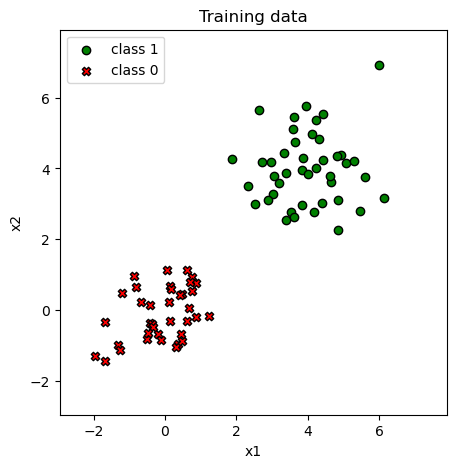

In [3]:
X, y = make_data(distance=4)
print("Shape:", X.shape, "| class 0:", (y == 0).sum(), "| class 1:", (y == 1).sum())
print("First rows:\n", np.round(X[:3], 2), y[:3])

Xtr, Xte, ytr, yte = split(X, y)
Xtr0 = add_x0(Xtr)
print(f"\ntrain: {len(ytr)} rows, test: {len(yte)} rows")

fig, ax = plt.subplots(figsize=(5, 5))
plot_lines(ax, Xtr, ytr, [], "Training data")
plt.show()

## Random start and one sample worked out

In [4]:
w = rng.uniform(-1, 1, 3).round(2)
print("Start w =", w)

y_hat, s = forward_pass(Xtr0[0], w)
calc = " + ".join(f"{xi:.2f}×{wi:.2f}" for xi, wi in zip(Xtr0[0], w))
print(f"s = {calc} = {s:.3f}  ->  step = {y_hat}  (target {ytr[0]})")

Start w = [-0.89 -0.65 -0.89]
s = -1.00×-0.89 + -1.32×-0.65 + -1.00×-0.89 = 2.637  ->  step = 1  (target 0)


## Train

In [5]:
w_final, history, mistakes = train(Xtr0, ytr, w, lr=0.1, epochs=50)
print(f"\nTrain accuracy: {accuracy(Xtr, ytr, w_final):.1f}%")
print(f"Test accuracy : {accuracy(Xte, yte, w_final):.1f}%")

Epoch   1 | mistakes  17/80 | w = [0.21  0.276 0.307]
Epoch   2 | mistakes   2/80 | w = [0.41  0.153 0.168]
Epoch   3 | mistakes   0/80 | w = [0.41  0.153 0.168]
Learned in 3 epochs

Train accuracy: 100.0%
Test accuracy : 100.0%


## Graphs

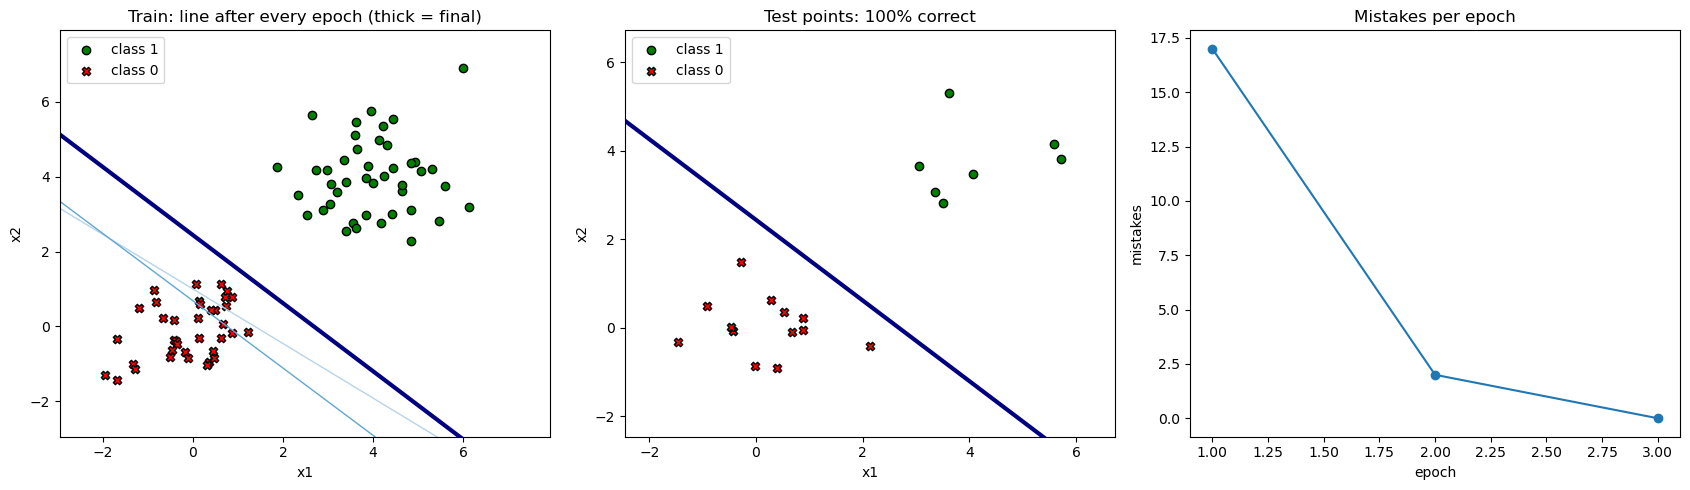

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot_lines(axes[0], Xtr, ytr, history, "Train: line after every epoch (thick = final)")
plot_lines(axes[1], Xte, yte, [w_final], f"Test points: {accuracy(Xte, yte, w_final):.0f}% correct")
axes[2].plot(range(1, len(mistakes) + 1), mistakes, "o-")
axes[2].set(xlabel="epoch", ylabel="mistakes", title="Mistakes per epoch")
plt.tight_layout()
plt.show()

---
# Experiments
## 1. Distance between the groups (same start, η = 0.1, 100 epochs, 20 random datasets each)

distance | learned | avg epochs | avg test acc
------------------------------------------------
       6 |  20/20  |        3.0 |        99.0%
       3 |   8/20  |       14.4 |        96.0%
       1 |   0/20  |          - |        61.8%


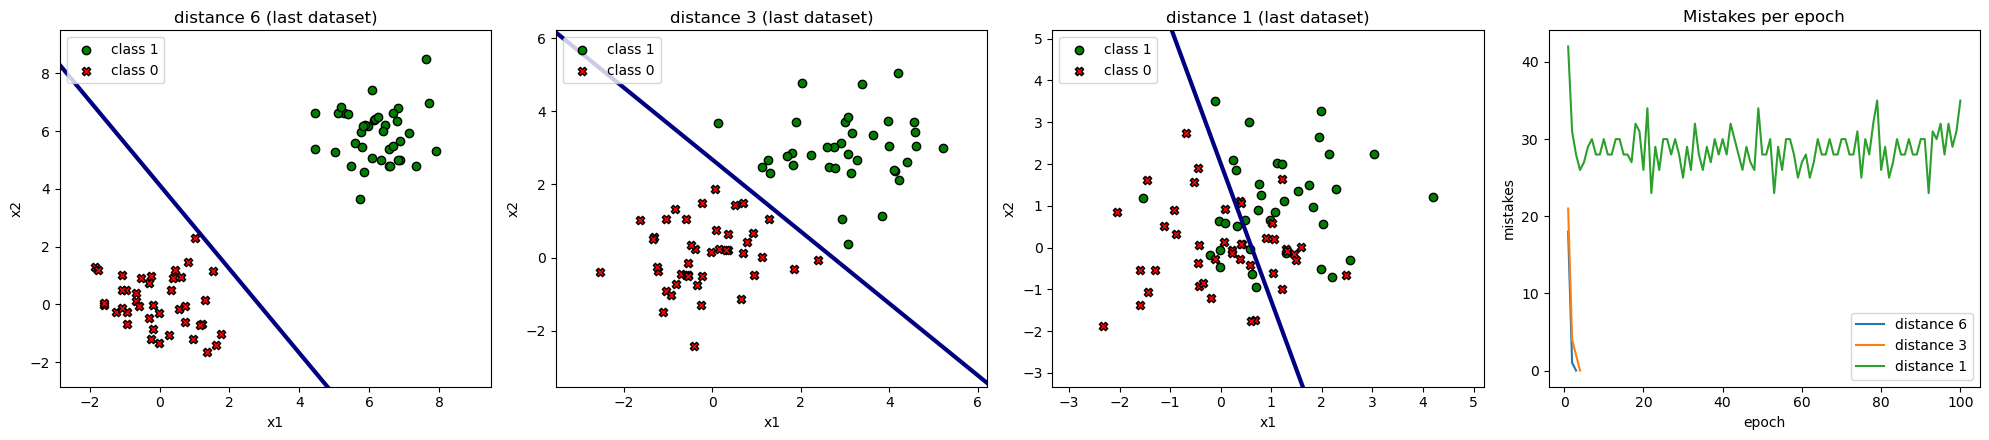

In [7]:
distances = [6, 3, 1]
fig, axes = plt.subplots(1, len(distances) + 1, figsize=(20, 4.5))
print(f"{'distance':>8} | {'learned':>7} | {'avg epochs':>10} | {'avg test acc':>12}")
print("-" * 48)
for ax, d in zip(axes, distances):
    runs = []
    for _ in range(20):
        Xd, yd = make_data(distance=d)
        Xd_tr, Xd_te, yd_tr, yd_te = split(Xd, yd)
        w_d, _, mis_d = train_quiet(add_x0(Xd_tr), yd_tr, w, 0.1, 100)
        runs.append((mis_d, accuracy(Xd_te, yd_te, w_d)))
    learned = [len(m) for m, _ in runs if m[-1] == 0]
    avg = f"{np.mean(learned):.1f}" if learned else "-"
    print(f"{d:>8} | {len(learned):>3}/20  | {avg:>10} | {np.mean([a for _, a in runs]):11.1f}%")
    plot_lines(ax, Xd_tr, yd_tr, [w_d], f"distance {d} (last dataset)")
    axes[-1].plot(range(1, len(mis_d) + 1), mis_d, label=f"distance {d}")
axes[-1].set(xlabel="epoch", ylabel="mistakes", title="Mistakes per epoch")
axes[-1].legend()
plt.tight_layout()
plt.show()

## 2. Learning rate (same data, same start)

       η | learned in | test acc
---------------------------------
  0.0001 |      never |    35.0%
   0.001 |  53 epochs |    95.0%
    0.01 |   6 epochs |    95.0%
     0.1 |   3 epochs |   100.0%
       1 |   2 epochs |   100.0%
      10 |   2 epochs |   100.0%


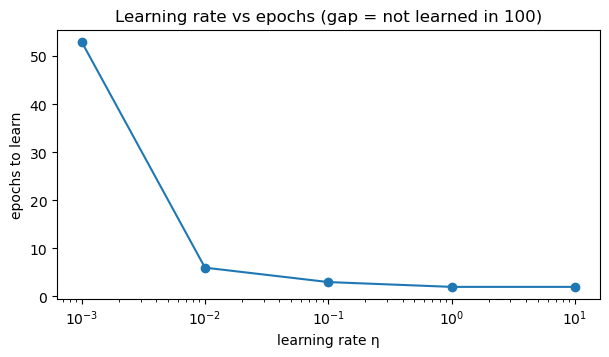

In [8]:
lrs = [0.0001, 0.001, 0.01, 0.1, 1, 10]
epochs_needed = []
print(f"{'η':>8} | {'learned in':>10} | {'test acc':>8}")
print("-" * 33)
for lr in lrs:
    w_lr, _, mis_lr = train_quiet(Xtr0, ytr, w, lr, 100)
    epochs_needed.append(len(mis_lr) if mis_lr[-1] == 0 else np.nan)
    learned = f"{len(mis_lr)} epochs" if mis_lr[-1] == 0 else "never"
    print(f"{lr:>8} | {learned:>10} | {accuracy(Xte, yte, w_lr):7.1f}%")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(lrs, epochs_needed, "o-")
ax.set(xscale="log", xlabel="learning rate η", ylabel="epochs to learn", title="Learning rate vs epochs (gap = not learned in 100)")
plt.show()

## 3. Different random starts ➜ different valid lines

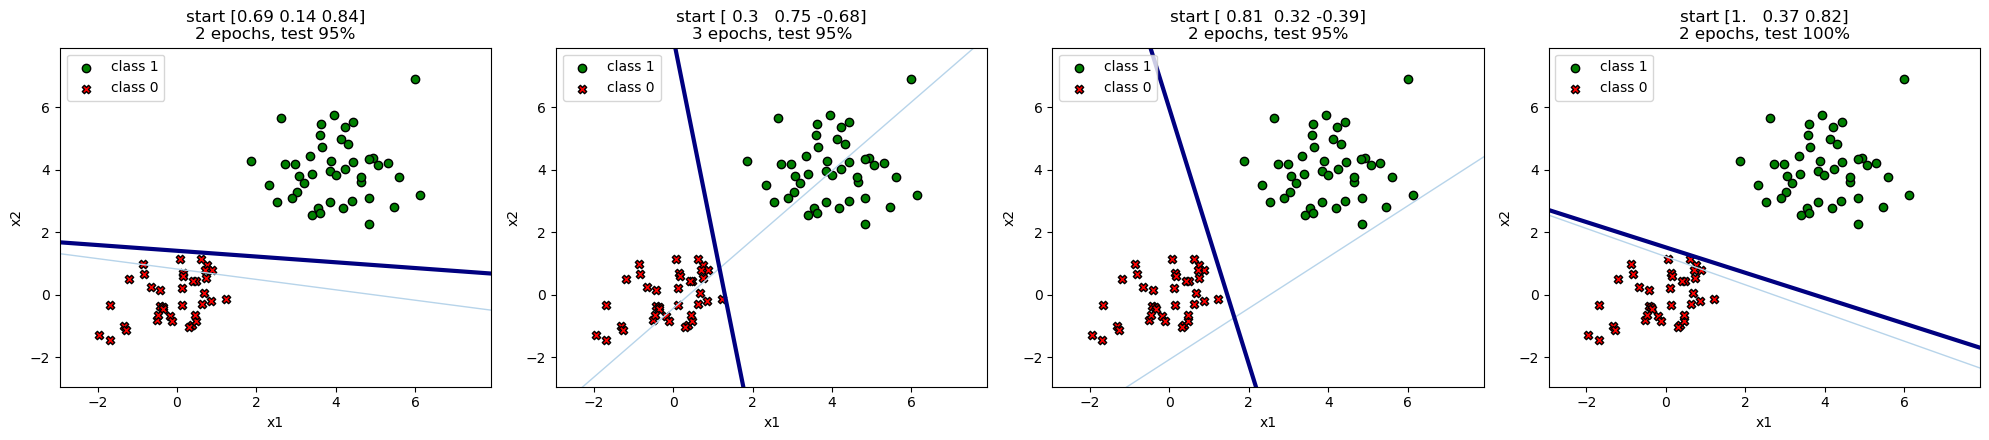

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax in axes:
    w_start = rng.uniform(-1, 1, 3).round(2)
    w_s, _, mis_s = train_quiet(Xtr0, ytr, w_start, 0.1, 100)
    plot_lines(ax, Xtr, ytr, [w_start, w_s], f"start {w_start}\n{len(mis_s)} epochs, test {accuracy(Xte, yte, w_s):.0f}%")
plt.tight_layout()
plt.show()